# Project: Visualizing Palmer Archipelago Penguin Data

## 分析目标

此数据分析报告的目的是对帕默群岛上企鹅样本的相关变量进行可视化，从而探索和分析种类、性别、所在岛屿等因素，与企鹅的身体属性，包括体重、嘴峰长度和深度、鳍的长度，之间的关系。

## 简介

原始数据`Penguins.csv`包括334个收集自南极洲帕尔默群岛的3个岛屿上的企鹅样本，以及企鹅相关属性数据，包括种类名、所在岛、嘴峰长度、嘴峰深度、鳍长度、体重、性别。

`Penguins.csv`每列的含义如下：
- species：企鹅的种类
- island：企鹅所在岛
- culmen_length_mm：企鹅嘴峰的长度（单位为毫米）
- culmen_depth_mm：企鹅嘴峰的深度（单位为毫米）
- flipper_length_mm：企鹅鳍的长度（单位为毫米）
- body_mass_g：企鹅体重（单位为克）
- sex：企鹅性别

## Access

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
original_data = pd.read_csv("Penguins.csv")
original_data.sample(10)

,species,island,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,sex
10,Adelie,Torgersen,37.8,17.1,186.0,3300.0,NaN
53,Adelie,Biscoe,42.0,19.5,200.0,4050.0,MALE
188,Chinstrap,Dream,47.6,18.3,195.0,3850.0,FEMALE
85,Adelie,Dream,41.3,20.3,194.0,3550.0,MALE
63,Adelie,Biscoe,41.1,18.2,192.0,4050.0,MALE
258,Gentoo,Biscoe,44.0,13.6,208.0,4350.0,FEMALE
162,Chinstrap,Dream,46.6,17.8,193.0,3800.0,FEMALE
79,Adelie,Torgersen,42.1,19.1,195.0,4000.0,MALE
112,Adelie,Biscoe,39.7,17.7,193.0,3200.0,FEMALE
49,Adelie,Dream,42.3,21.2,191.0,4150.0,MALE


## Clean

The dataset structure conforms to "each column is a variable, each row is an observation, and each cell is a value," therefore the focus is on cleaning the data content

In [5]:
original_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    object 
 1   island             344 non-null    object 
 2   culmen_length_mm   342 non-null    float64
 3   culmen_depth_mm    342 non-null    float64
 4   flipper_length_mm  342 non-null    float64
 5   body_mass_g        342 non-null    float64
 6   sex                334 non-null    object 
dtypes: float64(4), object(3)
memory usage: 18.9+ KB


From above, there is missing data in `culmen_length_mm`, `culmen_depth_mm`, `flipper_length_mm`, `body_mass_g`

`species`, `island` and `sex` can be converted into "category"

In [13]:
cleaned_data = original_data.copy()

# incorrect: mask = cleaned_data.isnull(), in this way, mask is a DataFrame that can't be used as condition
mask = cleaned_data.isnull().any(axis=1) # .any(axis=1) -- Indicates "aggregation along column direction," which means performing operations on each row
cleaned_data_with_nulls = cleaned_data[mask]
cleaned_data_with_nulls

,species,island,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,sex
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
8,Adelie,Torgersen,34.1,18.1,193.0,3475.0,NaN
9,Adelie,Torgersen,42.0,20.2,190.0,4250.0,NaN
10,Adelie,Torgersen,37.8,17.1,186.0,3300.0,NaN
11,Adelie,Torgersen,37.8,17.3,180.0,3700.0,NaN
47,Adelie,Dream,37.5,18.9,179.0,2975.0,NaN
246,Gentoo,Biscoe,44.5,14.3,216.0,4100.0,NaN
286,Gentoo,Biscoe,46.2,14.4,214.0,4650.0,NaN
324,Gentoo,Biscoe,47.3,13.8,216.0,4725.0,NaN
339,Gentoo,Biscoe,NaN,NaN,NaN,NaN,NaN


`sex` is an important variable when analysing, so the whole `cleaned_data_with_nulls` should be deleted

**Note**: I made a mistake, missing `sex` can be remained because it doesn't hinder the operation of `matplotlib` and `seaborn`

In [14]:
cleaned_data.dropna(inplace=True)
cleaned_data.isnull().sum()

species              0
island               0
culmen_length_mm     0
culmen_depth_mm      0
flipper_length_mm    0
body_mass_g          0
sex                  0
dtype: int64

In [15]:
cleaned_data.duplicated().sum()

np.int64(0)

In [23]:
cleaned_data = cleaned_data.astype({
    'species': 'category',
    'island': 'category',
    'sex': 'category'
})

cleaned_data.dtypes

species              category
island               category
culmen_length_mm      float64
culmen_depth_mm       float64
flipper_length_mm     float64
body_mass_g           float64
sex                  category
dtype: object

In [24]:
cleaned_data['species'].value_counts()

species
Adelie       146
Gentoo       120
Chinstrap     68
Name: count, dtype: int64

In [25]:
cleaned_data['island'].value_counts()

island
Biscoe       164
Dream        123
Torgersen     47
Name: count, dtype: int64

In [26]:
cleaned_data['sex'].value_counts()

sex
MALE      168
FEMALE    165
.           1
Name: count, dtype: int64

In [29]:
# apply mask() to convert "." into NaN
cleaned_data['sex'] = cleaned_data['sex'].mask(cleaned_data['sex'] == ".", np.nan)
cleaned_data['sex'] = cleaned_data['sex'].cat.remove_unused_categories()

cleaned_data['sex'].value_counts()

sex
MALE      168
FEMALE    165
Name: count, dtype: int64

In [31]:
cleaned_data.describe() # Don't forget to detect abnormal data

,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g
count,334.000000,334.000000,334.000000,334.000000
mean,43.994311,17.160479,201.014970,4209.056886
std,5.460521,1.967909,14.022175,804.836129
min,32.100000,13.100000,172.000000,2700.000000
25%,39.500000,15.600000,190.000000,3550.000000
50%,44.500000,17.300000,197.000000,4050.000000
75%,48.575000,18.700000,213.000000,4793.750000
max,59.600000,21.500000,231.000000,6300.000000


## Visualization

In [32]:
sns.set_palette("Set2")
cleaned_data

,species,island,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,MALE
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,FEMALE
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,FEMALE
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,FEMALE
5,Adelie,Torgersen,39.3,20.6,190.0,3650.0,MALE
...,...,...,...,...,...,...,...
338,Gentoo,Biscoe,47.2,13.7,214.0,4925.0,FEMALE
340,Gentoo,Biscoe,46.8,14.3,215.0,4850.0,FEMALE
341,Gentoo,Biscoe,50.4,15.7,222.0,5750.0,MALE
342,Gentoo,Biscoe,45.2,14.8,212.0,5200.0,FEMALE


### species/island/sex proportion

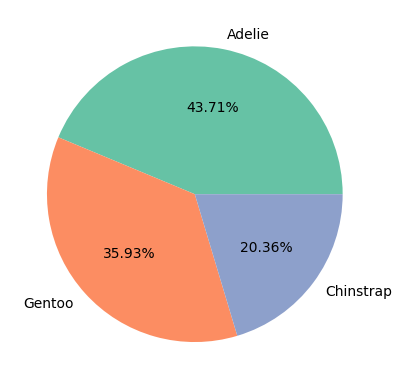

In [39]:
# plt.pie() won't count the number of species automatically
species_count = cleaned_data['species'].value_counts()

plt.pie(species_count,
        labels=species_count.index,
        autopct='%.2f%%')
plt.show()

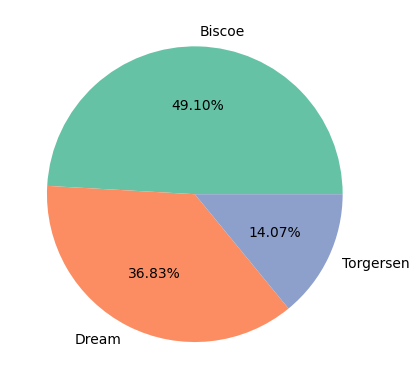

In [40]:
island_count = cleaned_data['island'].value_counts()

plt.pie(island_count,
        labels=island_count.index,
        autopct='%.2f%%')
plt.show()

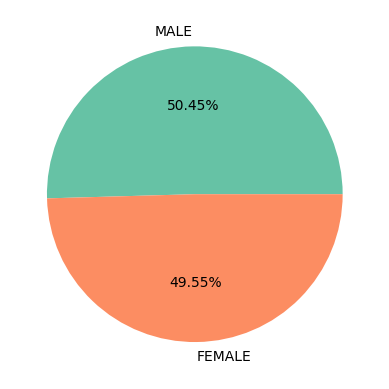

In [41]:
sex_count = cleaned_data['sex'].value_counts()

plt.pie(sex_count,
        labels=sex_count.index,
        autopct='%.2f%%')
plt.show()

### number of species/sex on different island

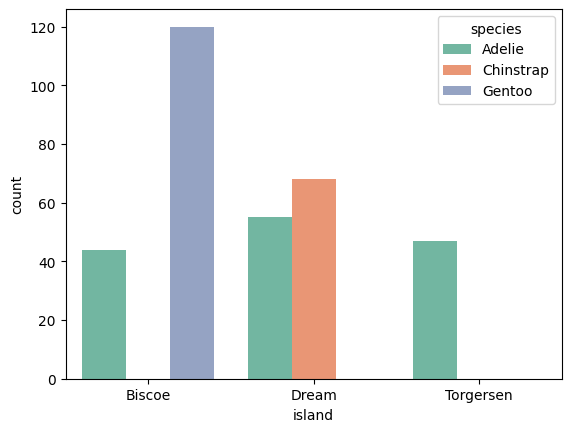

In [44]:
sns.countplot(cleaned_data, x='island', hue='species')
plt.show()

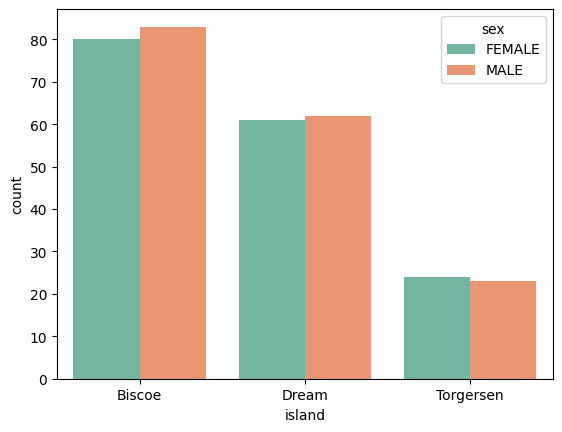

In [45]:
sns.countplot(cleaned_data, x='island', hue='sex')
plt.show()

### correlation bewteen numerical values based on species/sex

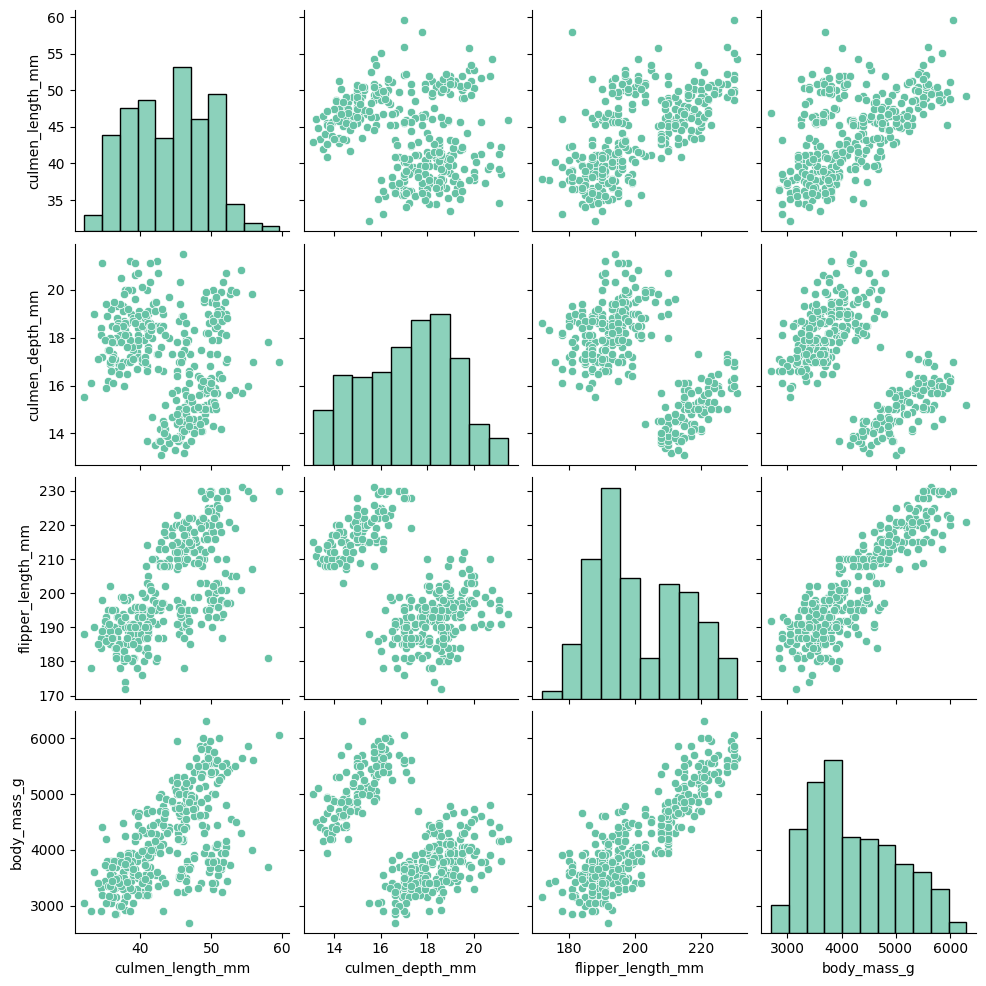

In [46]:
sns.pairplot(cleaned_data)
plt.show()

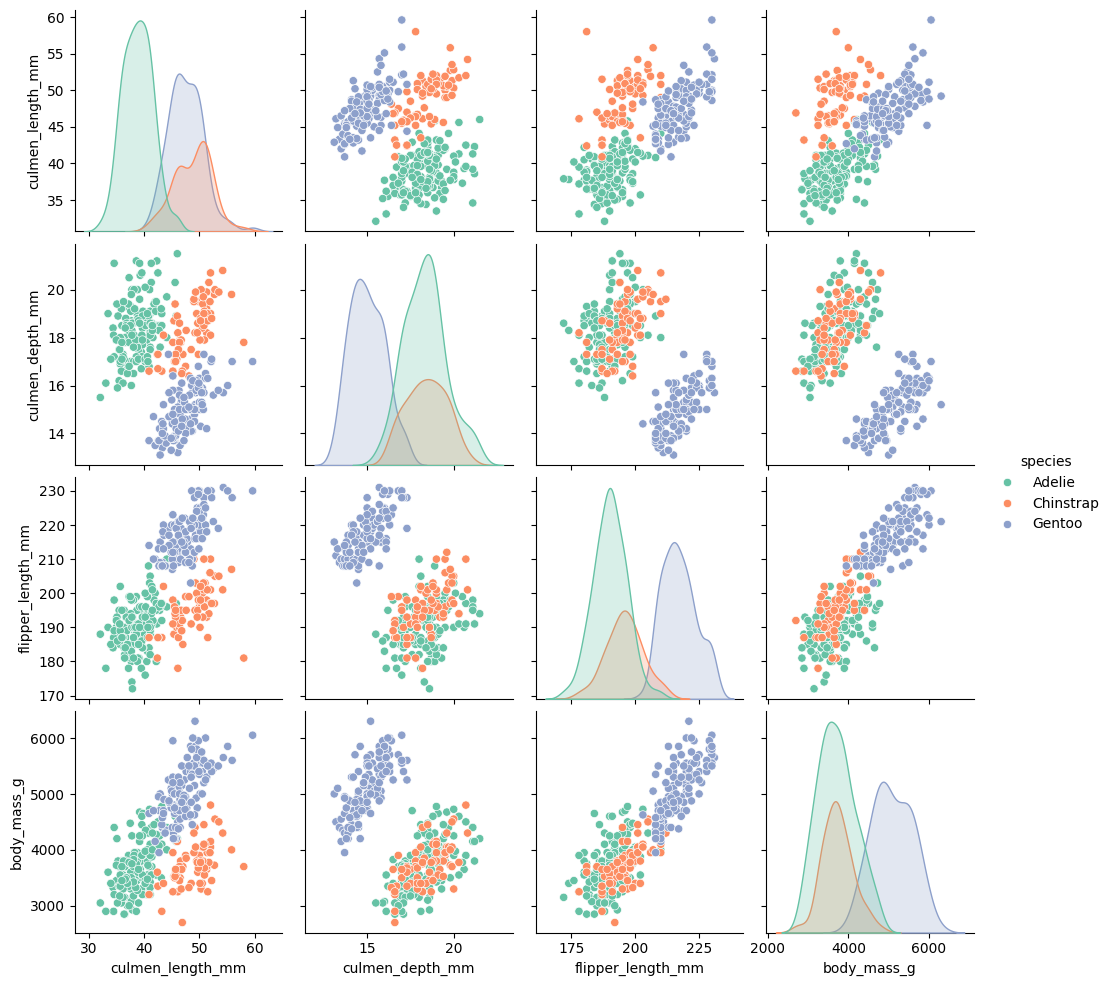

In [47]:
sns.pairplot(cleaned_data, hue='species')
plt.show()

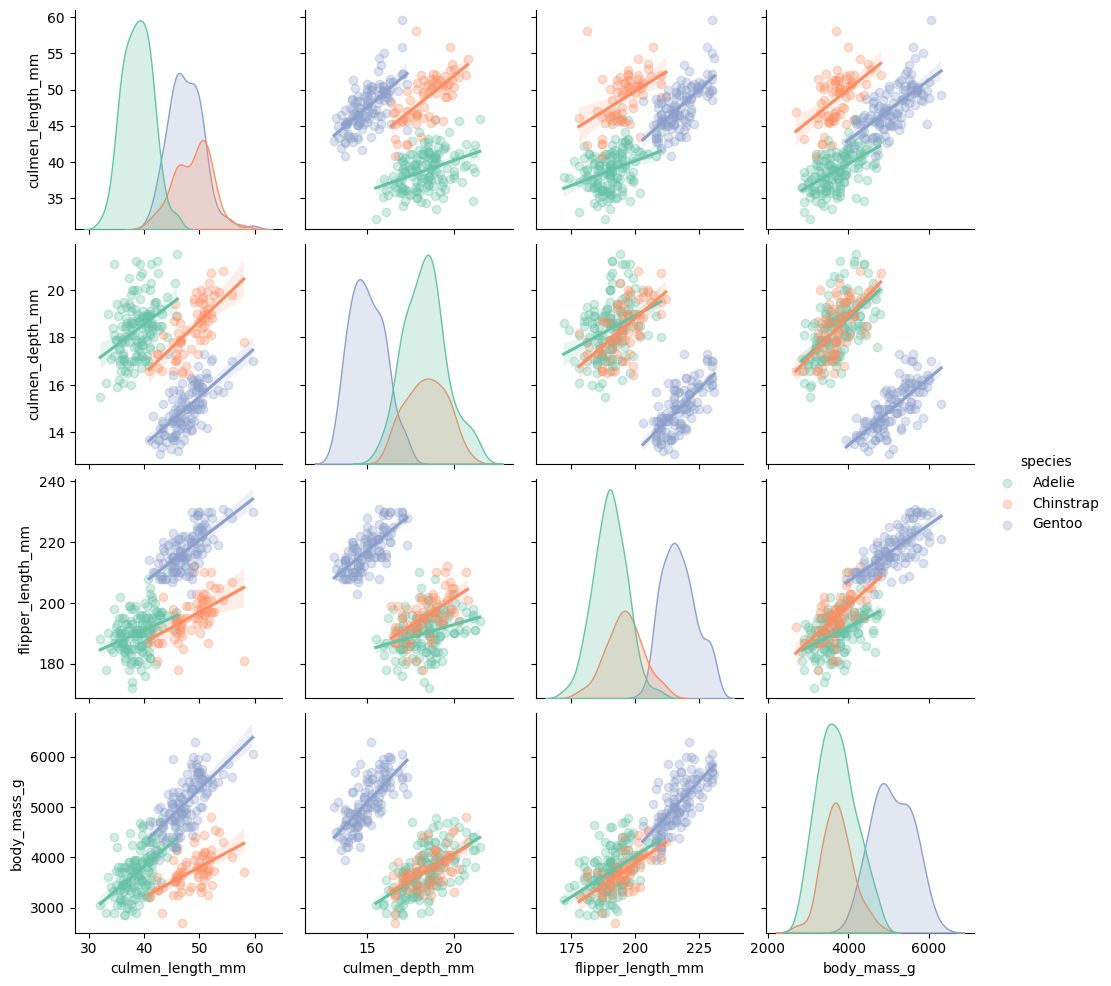

In [49]:
sns.pairplot(cleaned_data, hue='species', kind='reg', plot_kws={'scatter_kws': {'alpha': 0.3}})
plt.show()

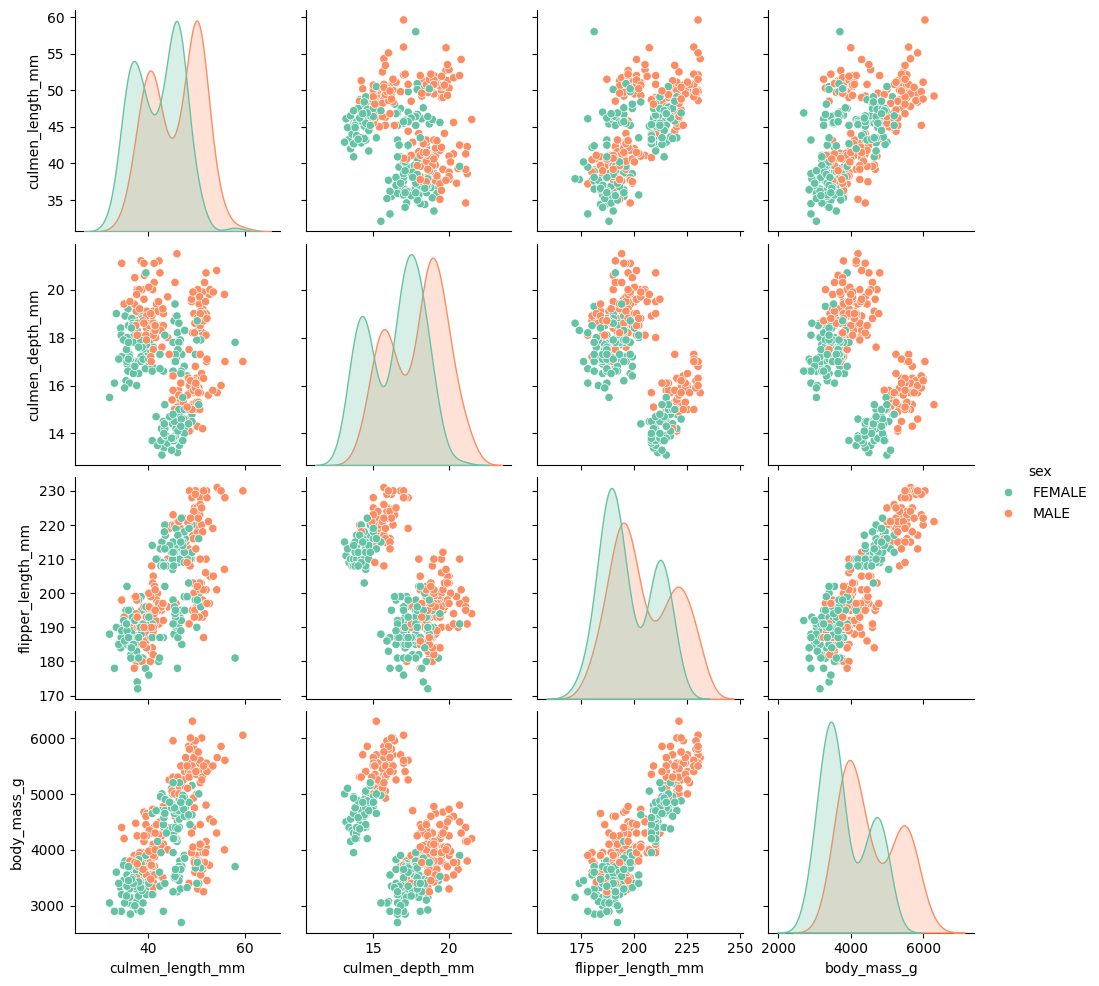

In [48]:
sns.pairplot(cleaned_data, hue='sex')
plt.show()